In [1]:
# %run validation.py --explanation_type=Self --seed=42

In [2]:

# from load_experiment_data import (
#     train_dataset_name,
#     test_dataset_name,
#     train_dataset_split,
#     test_dataset_split,
#     load_data_and_estimators,
#     explanation_types,
#     linear_coders,
#     explanation_seed,
#     explanation_k
# )
# train_dataset, test_dataset, estimators = load_data_and_estimators()

In [3]:
# from explanations import TopKMostInfluential,TopKLeastInfluential

In [4]:
# explanation = TopKMostInfluential(99,estimators[0],k=10)
# explanation.documents

In [5]:
# explanation.description

In [6]:
# train_dataset.select(explanation.documents)["messages"]

In [7]:
# train_dataset.select([explanation.document_idx])["messages"]

In [8]:
# TopKMostInfluential(1,estimators[1],k=10).documents

In [9]:
# trd6i7fogizöul

In [10]:
# %run merge_results.py

In [11]:
import os
# from multiprocess import set_start_method
# set_start_method("spawn")
import logging
logger = logging.getLogger("ignite.handlers.early_stopping.EarlyStopping")
logger.setLevel(logging.WARNING)

In [12]:



import os
import torch

import argparse



In [13]:
# from load_experiment_data import (
#     train_dataset_name,
#     test_dataset_name,
#     train_dataset_split,
#     test_dataset_split,
#     load_data_and_estimators,
#     explanation_types,
#     linear_coders,
#     explanation_seed,
#     explanation_k
# )
# # train_dataset, test_dataset, estimators = load_data_and_estimators()


In [14]:
# from functools import partial
# from explanations import KRandom
# k_random_types = [partial(KRandom, seed=s) for s in range(9)]
# explanation_types = explanation_types + k_random_types

In [15]:
# import logging
# from concurrent.futures import ProcessPoolExecutor, as_completed
# import torch
# import multiprocessing
# from tqdm import tqdm
# import itertools
# import pandas as pd
# import traceback

# logging.basicConfig(level=logging.ERROR, format='%(asctime)s [%(levelname)s] %(message)s')
# multiprocessing.set_start_method('spawn', force=True)
# torch.manual_seed(42)




# num_devices = torch.cuda.device_count()







In [16]:
import glob
import pandas as pd
import os

In [17]:
import pyarrow as pa
import pyarrow.parquet as pq

In [18]:
df_validation = pq.ParquetDataset("results/validation").read().to_pandas()


In [19]:
# df_scoring = merge_fragments_with_source_column_parallel( source_dir="cache/scoring/partial", target_dir="results/scoring")
# df_scoring["linear_coder"] = df_scoring["source_file"].apply(lambda path: os.path.basename(os.path.dirname(os.path.dirname(path))))

In [20]:
# df_scoring = load_or_merge_dataset( source_dir="cache/scoring/partial", target_dir="cache/scoring/full")
# df_scoring["linear_coder"] = df_scoring["source_file"].apply(lambda path: os.path.basename(os.path.dirname(os.path.dirname(path))))

In [21]:
# df_scoring = load_or_merge_dataset(
#     source_dir="cache/scoring/partial",
#     target_dir="cache/scoring/full"
# )


# df_scoring["linear_coder"] = df_scoring["source_file"].apply(
#     lambda path: os.path.basename(os.path.dirname(os.path.dirname(path)))
# )

In [22]:
import re

In [23]:

def rename_model(x):
       if x == "OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr0.0001_seed42":
              return "Olmo2-1B"
       
def rename_estimator(x):
      return x.split(":")[0]
def rename_linear_coder(x):
      return x.replace("Coder","").replace("Thresh","")
def extract_seed(x):
       return int(re.search(r'seed (\d+)', x).group(1)) if "seed" in x else None

def rename_random(x):
    return re.sub(r' with seed \d+', "", x)



In [24]:
df_validation["model"]  = df_validation["model"].apply(rename_model)
df_validation["estimator"]  = df_validation["estimator"].apply(rename_estimator)


In [25]:
import re

def extract_k(explanation_type):
    # Case: "The test instance (as a sanity check)"
    if "The test instance (as a sanity check)" in explanation_type:
        return 1

    # Case: "<number> by ... from Top-..."
    first_number_match = re.match(r"^\s*(\d+)\b", explanation_type)
    if first_number_match:
        return int(first_number_match.group(1))

    # Case: "Top-<number> ..." when no leading number
    top_match = re.search(r"Top-(\d+)", explanation_type)
    if top_match:
        return int(top_match.group(1))

    # Case: "<number> random examples"
    random_match = re.search(r"(\d+)\s+random examples", explanation_type)
    if random_match:
        return int(random_match.group(1))

    return None

# Apply to dataframe
df_validation["k"] = df_validation["explanation_type"].apply(extract_k)

# Replace the first occurrence of k in the string with "X"
def replace_k(explanation_type, k):
    if k is None:
        return explanation_type
    # Only replace the first occurrence of the number as a standalone word
    return re.sub(rf"\b{k}\b", "X", explanation_type, count=1)


import numpy as np

def vectorized_replace_k(explanation_types, ks):
    result = explanation_types.copy()
    for k in np.unique(ks[ks.notnull()]):  # only unique, non-null ks
        # Use string pattern, not compiled regex
        pattern = rf"\b{k}\b"
        mask = ks == k
        result.loc[mask] = result.loc[mask].str.replace(pattern, "X", n=1, regex=True)
    return result
df_validation["explanation_type_no_k"] = vectorized_replace_k(df_validation["explanation_type"], df_validation["k"])


def facility_location_hotfix(x):
    if ("facility" in x) and x.startswith("Top-"):
        return x[len("Top-"):]
    else:
        return x
        
df_validation["explanation_type"] = df_validation["explanation_type"].apply(facility_location_hotfix) # hotfix: inconsistent naming scheme for facility location selections


def get_sort_type(x):
    for sort_type in ["scores with largest absolute value", "most positive scores", "most negative scores", "scores closest to zero"]:
        if sort_type in x:
            return sort_type
    return "-"
df_validation["sort_type"] = df_validation["explanation_type"].apply(get_sort_type)

In [26]:
df_validation_random = df_validation[df_validation["explanation_type"].str.contains("42")]#"random examples with seed")]
df_validation_selection = df_validation[~df_validation["explanation_type"].str.contains("42")]#"random examples with seed")]


In [27]:
r = pd.merge(
                df_validation_selection,
                df_validation_random,
                on=[
                    "model",
                    "estimator",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                    "document_idx"
                ],
                suffixes=("_selection", "_random"),
                how="inner"
            )
r["validation_score_log_p"] = r["delta_log_p_selection"] >= r["delta_log_p_random"]
r["validation_score_jsd"] = r["jsd_selection"] >= r["jsd_random"]
r["validation_score_kld"] = r["kld(before||after)_selection"] >= r["kld(before||after)_random"]
r_summary = r.groupby([         "estimator",
                     "explanation_type_selection",
                    "model",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                ]).agg(
                    mean_validation_score_log_p=("validation_score_log_p", "mean"),
                    count_validation_score_log_p=("validation_score_log_p", "count"),
                    mean_validation_score_jsd=("validation_score_jsd", "mean"),
                    count_validation_score_jsd=("validation_score_jsd", "count"),
                    mean_validation_score_kld=("validation_score_kld", "mean"),
                    count_validation_score_kld=("validation_score_kld", "count")
                    )

r_summary.reset_index().style.background_gradient(subset=["mean_validation_score_log_p","mean_validation_score_jsd"], cmap="PuBu", ).format({"mean_validation_score_log_p": "{:.2f}","mean_validation_score_jsd": "{:.2f}"})\
    .hide(axis="columns", subset=["k", "train_dataset", "train_split", "test_dataset","test_split","count_validation_score_log_p","count_validation_score_kld", "count_validation_score_jsd","mean_validation_score_kld"]).hide(axis="index")

estimator,explanation_type_selection,model,mean_validation_score_log_p,mean_validation_score_jsd
DataInfEstimator,10 random examples with seed 10,Olmo2-1B,0.43,0.47
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,0.48,0.47
DataInfEstimator,5 random examples with seed 10,Olmo2-1B,0.46,0.48
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,0.50,0.58


In [28]:
# %run merge_results.py --source_dir="cache/scoring/partial" --target_dir="results/scoring"

In [38]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

df_scoring = pq.ParquetDataset("results/scoring").read().to_pandas()
df_scoring["k"] = df_scoring["explanation_type"].apply(extract_k)
df_scoring["explanation_type_no_k"] = df_scoring.apply(
    lambda row: row["explanation_type"].replace(str(row["k"]), "X"),
    axis=1
)
df_scoring["explanation_type"] = df_scoring["explanation_type"].apply(facility_location_hotfix) # hotfix: inconsistent naming scheme for facility location selections
df_scoring["model"] = df_scoring["model"].apply(rename_model)
df_scoring["estimator"] = df_scoring["estimator"].apply(rename_estimator)

In [39]:
from scipy.stats import spearmanr, pearsonr


In [42]:

rr = pd.merge(
    r,
    df_scoring,
    left_on=[
        "model",
        "estimator",
        "train_dataset",
        "train_split",
        "test_dataset",
        "test_split",
        "explanation_type_selection", 
        "k",
        "document_idx"
    ],
    right_on=[
        "model",
        "estimator",
        "train_dataset",
        "train_split",
        "test_dataset",
        "test_split",
        "explanation_type", 
        "k",
        "document_idx"
    ],
    suffixes=("_validation", "_scoring"),
    how="left"
)
rr["validation_score_log_p"] = rr["delta_log_p_selection"] >= rr["delta_log_p_random"]
rr["validation_score_jsd"] = rr["jsd_selection"] >= rr["jsd_random"]
rr["validation_score_kld"] = rr["kld(before||after)_selection"] >= rr["kld(before||after)_random"]


rr_summary = rr.groupby([
    "estimator",
    "explanation_type_selection",
    "model",
    "train_dataset",
    "train_split",
    "test_dataset",
    "test_split",
    "k",
    "linear_coder",
    "explanation_type_no_k_selection",
]).agg(
    mean_pred_gain=("pred_gain", "mean"),
    mean_mse=("mse", "mean"),
    mean_validation_score_log_p=("validation_score_log_p", "mean"),
    count_validation_score_log_p=("validation_score_log_p", "count"),
    mean_validation_score_jsd=("validation_score_jsd", "mean"),
    count_validation_score_jsd=("validation_score_jsd", "count"),
    mean_validation_score_kld=("validation_score_kld", "mean"),
    count_validation_score_kld=("validation_score_kld", "count")
)

                
                      
                

rr_summary.sort_values(by="mean_mse", ascending=True)\
    .reset_index().style.background_gradient(subset=["mean_mse","mean_validation_score_log_p","mean_validation_score_jsd"], cmap="PuBu", ).format({"mean_validation_score_log_p": "{:.2f}","mean_validation_score_jsd": "{:.2f}"})\
    .hide(axis="columns", subset=["k", "mean_pred_gain","train_dataset", "train_split", "test_dataset","test_split","count_validation_score_log_p","count_validation_score_kld", "count_validation_score_jsd","mean_validation_score_kld"]).hide(axis="index")

estimator,explanation_type_selection,model,linear_coder,explanation_type_no_k_selection,mean_mse,mean_validation_score_log_p,mean_validation_score_jsd
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,MSECoder,X random examples with seed 3,0.000004,0.50,0.58
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,KLTCoder,X random examples with seed 3,0.000004,0.50,0.58
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,MSECoderNNLSL2,X random examples with seed 3,0.000004,0.50,0.58
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,MSECoderProjUSimp,X random examples with seed 3,0.000005,0.50,0.58
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,MSECoderProjUSimpSparseSoftThresh,X random examples with seed 3,0.000005,0.50,0.58
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,MSECoderProjUSimpSparse,X random examples with seed 3,0.000005,0.50,0.58
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,MSECoder,X random examples with seed 10,0.000023,0.48,0.47
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,KLTCoder,X random examples with seed 10,0.000023,0.48,0.47
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,MSECoderNNLSL2,X random examples with seed 10,0.000023,0.48,0.47
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,MSECoderProjUSimp,X random examples with seed 10,0.000024,0.48,0.47


In [52]:
da = rr_summary.reset_index()
da.columns

Index(['estimator', 'explanation_type_selection', 'model', 'train_dataset',
       'train_split', 'test_dataset', 'test_split', 'k', 'linear_coder',
       'explanation_type_no_k_selection', 'mean_pred_gain', 'mean_mse',
       'mean_validation_score_log_p', 'count_validation_score_log_p',
       'mean_validation_score_jsd', 'count_validation_score_jsd',
       'mean_validation_score_kld', 'count_validation_score_kld'],
      dtype='object')

,estimator,explanation_type_selection,model,train_dataset,train_split,test_dataset,test_split,k,linear_coder,explanation_type_no_k_selection,mean_pred_gain,mean_mse,mean_validation_score_log_p,count_validation_score_log_p,mean_validation_score_jsd,count_validation_score_jsd,mean_validation_score_kld,count_validation_score_kld
0,DataInfEstimator,10 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,10,KLTCoder,X random examples with seed 10,0.968004,0.000029,0.431034,116,0.465517,116,0.465517,116
1,DataInfEstimator,10 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,10,MSECoder,X random examples with seed 10,0.968049,0.000029,0.431034,116,0.465517,116,0.465517,116
2,DataInfEstimator,10 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,10,MSECoderNNLSL2,X random examples with seed 10,0.967779,0.000029,0.431034,116,0.465517,116,0.465517,116
3,DataInfEstimator,10 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,10,MSECoderProjUSimp,X random examples with seed 10,0.702231,0.000030,0.431034,116,0.465517,116,0.465517,116
4,DataInfEstimator,10 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,10,MSECoderProjUSimpSparse,X random examples with seed 10,0.627733,0.000030,0.431034,116,0.465517,116,0.465517,116
5,DataInfEstimator,10 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,10,MSECoderProjUSimpSparseSoftThresh,X random examples with seed 10,0.697362,0.000030,0.431034,116,0.465517,116,0.465517,116
6,DataInfEstimator,25 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,25,KLTCoder,X random examples with seed 10,0.974267,0.000023,0.480000,100,0.470000,100,0.460000,100
7,DataInfEstimator,25 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,25,MSECoder,X random examples with seed 10,0.974268,0.000023,0.480000,100,0.470000,100,0.460000,100
8,DataInfEstimator,25 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,25,MSECoderNNLSL2,X random examples with seed 10,0.972585,0.000023,0.480000,100,0.470000,100,0.460000,100
9,DataInfEstimator,25 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,25,MSECoderProjUSimp,X random examples with seed 10,0.808875,0.000024,0.480000,100,0.470000,100,0.460000,100


In [45]:
from scipy.stats import spearmanr, pearsonr
rr_summary_ = rr_summary.reset_index()[rr_summary.reset_index()["linear_coder"] == "MSECoderProjUSimpSparse"]
def compute_group_correlations(row):
    subset = rr[
        (rr["estimator"] == row["estimator"]) &
        (rr["explanation_type_selection"] == row["explanation_type_selection"]) &
        (rr["model"] == row["model"]) &
        (rr["train_dataset"] == row["train_dataset"]) &
        (rr["train_split"] == row["train_split"]) &
        (rr["test_dataset"] == row["test_dataset"]) &
        (rr["test_split"] == row["test_split"]) &
        (rr["k"] == row["k"]) &
        (rr["linear_coder"] == row["linear_coder"]) &
        (rr["explanation_type_no_k_selection"] == row["explanation_type_no_k_selection"])
    ]

    if len(subset) < 2:
        return pd.Series([float('nan')]*8)  # now 8 values
    
    s_logp = spearmanr(subset["mse"], subset["validation_score_log_p"])
    s_jsd  = spearmanr(subset["mse"], subset["validation_score_jsd"])
    p_logp = pearsonr(subset["mse"], subset["validation_score_log_p"])
    p_jsd  = pearsonr(subset["mse"], subset["validation_score_jsd"])

    return pd.Series([
        s_logp.correlation, s_jsd.correlation,   # Spearman rhos
        p_logp[0], p_jsd[0],                     # Pearson r
        s_logp.pvalue, s_jsd.pvalue,             # Spearman p-values
        p_logp[1], p_jsd[1]                      # Pearson p-values
    ])

rr_summary_[[
    "spearman_mse_log_p_rho",
    "spearman_mse_jsd_rho",
    "pearson_mse_log_p_r",
    "pearson_mse_jsd_r",
    "spearman_mse_log_p_pval",
    "spearman_mse_jsd_pval",
    "pearson_mse_log_p_pval",
    "pearson_mse_jsd_pval"
]] = rr_summary_.reset_index().apply(compute_group_correlations, axis=1).values

rr_summary_


def format_corr_with_stars(corr, p):
    if pd.isna(corr):
        return ''
    # Determine stars based on p-value
    if pd.isna(p):
        stars = ''
    elif p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    else:
        stars = ''
    return f"{corr:.2f}{stars}"

def compute_group_correlations(row):
    subset = rr[
        (rr["estimator"] == row["estimator"]) &
        (rr["explanation_type_selection"] == row["explanation_type_selection"]) &
        (rr["model"] == row["model"]) &
        (rr["train_dataset"] == row["train_dataset"]) &
        (rr["train_split"] == row["train_split"]) &
        (rr["test_dataset"] == row["test_dataset"]) &
        (rr["test_split"] == row["test_split"]) &
        (rr["k"] == row["k"]) &
        (rr["linear_coder"] == row["linear_coder"]) &
        (rr["explanation_type_no_k_selection"] == row["explanation_type_no_k_selection"])
    ]

    if len(subset) < 2:
        return pd.Series(['']*4)  # 4 columns: Spearman log_p, Spearman jsd, Pearson log_p, Pearson jsd

    # Compute correlations
    s_logp = spearmanr(subset["mse"], subset["validation_score_log_p"])
    s_jsd  = spearmanr(subset["mse"], subset["validation_score_jsd"])
    p_logp = pearsonr(subset["mse"], subset["validation_score_log_p"])
    p_jsd  = pearsonr(subset["mse"], subset["validation_score_jsd"])

    return pd.Series([
        format_corr_with_stars(s_logp.correlation, s_logp.pvalue),
        format_corr_with_stars(s_jsd.correlation, s_jsd.pvalue),
        format_corr_with_stars(p_logp[0], p_logp[1]),
        format_corr_with_stars(p_jsd[0], p_jsd[1])
    ])

# Apply to your dataframe
rr_summary_[[
    "spearman_mse_log_p",
    "spearman_mse_jsd",
    "pearson_mse_log_p",
    "pearson_mse_jsd"
]] = rr_summary_.reset_index().apply(compute_group_correlations, axis=1).values



styled = rr_summary_.reset_index().sort_values(by="spearman_mse_jsd").style.hide(axis="index").hide(axis="columns", subset=[
      "estimator", 
      "k", "mean_pred_gain","train_dataset", "train_split",
        "test_dataset","test_split","count_validation_score_log_p",
        "count_validation_score_kld", "count_validation_score_jsd",
        "mean_validation_score_kld","model","explanation_type_no_k_selection",
        "spearman_mse_log_p_rho",	"spearman_mse_jsd_rho",	"pearson_mse_log_p_r",	"pearson_mse_jsd_r","linear_coder",	"spearman_mse_log_p_pval",	"spearman_mse_jsd_pval",	"pearson_mse_log_p_pval",	"pearson_mse_jsd_pval"
    ])

import pandas as pd
import re

# --- 1. Custom Heatmap Background Coloring Function (PuBu Sequential) ---

def get_background_color_from_corr_pubu(val):
    """
    Extracts the absolute numeric correlation and sets a PuBu sequential 
    background color (darker for stronger correlation, regardless of sign).
    """
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'background-color: white'
    
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'background-color: white'

    abs_corr = abs(corr)
    abs_corr = max(0.0, min(1.0, abs_corr)) 
    
    # Custom PuBu approximation: Interpolate RGB components from White (255) to Dark Blue/Purple
    DARK_R, DARK_G, DARK_B = 50, 150, 200  # Target dark end color
    WHITE = 255
    
    # Interpolate RGB components from White (255) to the Dark end
    r = int(WHITE - abs_corr * (WHITE - DARK_R))
    g = int(WHITE - abs_corr * (WHITE - DARK_G))
    b = int(WHITE - abs_corr * (WHITE - DARK_B))

    return f'background-color: rgb({r}, {g}, {b})'


# --- 2. Custom Text Contrast Coloring Function (White/Black) ---

def get_text_color_for_contrast_pubu(val):
    """
    Sets text color to white (dark background) or black (light background) for contrast.
    """
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'color: black'
    
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'color: black'

    # Use white text when the absolute correlation (background darkness) is 0.6 or higher
    if abs(corr) >= 0.6:
        return 'color: white'
    else:
        return 'color: black'




correlation_cols = [
    "spearman_mse_log_p",
    "spearman_mse_jsd",
    "pearson_mse_log_p",
    "pearson_mse_jsd"
]
colnames = {
    "explanation_type_selection": "Selection", 
    "spearman_mse_log_p": "$\\rho (mse, \\log_p)$", 
    "mean_mse": "MSE",
    "mean_validation_score_log_p": "$\\Delta \\log_p$",
    "mean_validation_score_jsd": "$JSD$",
    "spearman_mse_jsd": "$\\rho (mse, JSD)$",
    "pearson_mse_log_p": "$r (mse, \\log_p)$",
    "pearson_mse_jsd": "$r (mse, JSD)$"
    
    }
# display(styled)

styled_heatmap = styled.map(get_background_color_from_corr_pubu, subset=correlation_cols).format_index(colnames.get, axis=1)

styled_final = styled_heatmap.map(get_text_color_for_contrast_pubu, subset=correlation_cols).format({col: "{:.2f}" for col in styled_heatmap.data.select_dtypes(include="number").columns})


display(styled_final)
os.makedirs("./tables", exist_ok=True)


latex_tabular = (
    styled_final
    .format_index(colnames.get, axis=1)
    .format_index(escape="latex", axis=0)
    .to_latex(convert_css=True, hrules=True, column_format='l' + 'l'*(len(styled_final.data.columns)))
)

latex_table = (
"\\begin{table*}[htbp]\n"
"\\scriptsize\n"
  "\\caption{Correlation of our score (MSE) with two fine-tuning based scores measuring increase in prob of test instance, and shift in prob distribution.}\label{tab:validation}\n "
"\\centering\n"
        f"{latex_tabular}\n"
"\\end{table*}\n"
)


with open(f"./tables/validation_full.tex", "w") as f:
        f.write(latex_table)
# print(latex_table)

None,Selection,MSE,$\Delta \log_p$,$JSD$,"$\rho (mse, \log_p)$","$\rho (mse, JSD)$","$r (mse, \log_p)$","$r (mse, JSD)$"
4.00,10 random examples with seed 10,0.00,0.43,0.47,0.05,-0.03,-0.09,-0.15
10.00,25 random examples with seed 10,0.00,0.48,0.47,0.05,-0.03,-0.10,0.08
22.00,5 random examples with seed 3,0.00,0.50,0.58,0.25,-0.20,0.23,-0.26
16.00,5 random examples with seed 10,0.00,0.46,0.48,-0.16,0.04,-0.15,0.01


Selection,MSE,$\Delta \log_p$,$JSD$,"$\rho (mse, \log_p)$","$\rho (mse, JSD)$","$r (mse, \log_p)$","$r (mse, JSD)$"
10 random examples with seed 10,0.00,0.43,0.47,0.05,-0.03,-0.09,-0.15
25 random examples with seed 10,0.00,0.48,0.47,0.05,-0.03,-0.10,0.08
5 random examples with seed 3,0.00,0.50,0.58,0.25,-0.20,0.23,-0.26
5 random examples with seed 10,0.00,0.46,0.48,-0.16,0.04,-0.15,0.01


In [ ]:
styled_final.columns

Index(['estimator', 'explanation_type_selection', 'model', 'train_dataset',
       'train_split', 'test_dataset', 'test_split', 'k', 'linear_coder',
       'explanation_type_no_k_selection', 'mean_pred_gain', 'mean_mse',
       'mean_validation_score_log_p', 'count_validation_score_log_p',
       'mean_validation_score_jsd', 'count_validation_score_jsd',
       'mean_validation_score_kld', 'count_validation_score_kld',
       'spearman_mse_log_p_rho', 'spearman_mse_jsd_rho', 'pearson_mse_log_p_r',
       'pearson_mse_jsd_r', 'spearman_mse_log_p_pval', 'spearman_mse_jsd_pval',
       'pearson_mse_log_p_pval', 'pearson_mse_jsd_pval', 'spearman_mse_log_p',
       'spearman_mse_jsd', 'pearson_mse_log_p', 'pearson_mse_jsd'],
      dtype='object')

In [ ]:
styled.columns

Index(['estimator', 'explanation_type_selection', 'model', 'train_dataset',
       'train_split', 'test_dataset', 'test_split', 'k', 'linear_coder',
       'explanation_type_no_k_selection', 'mean_pred_gain', 'mean_mse',
       'mean_validation_score_log_p', 'count_validation_score_log_p',
       'mean_validation_score_jsd', 'count_validation_score_jsd',
       'mean_validation_score_kld', 'count_validation_score_kld',
       'spearman_mse_log_p_rho', 'spearman_mse_jsd_rho', 'pearson_mse_log_p_r',
       'pearson_mse_jsd_r', 'spearman_mse_log_p_pval', 'spearman_mse_jsd_pval',
       'pearson_mse_log_p_pval', 'pearson_mse_jsd_pval'],
      dtype='object')

In [ ]:
hbkfuldrviüä

NameError: name 'hbkfuldrviüä' is not defined

In [ ]:
rr_summary

mean_pred_gain  \
estimator        explanation_type_selection      model    train_dataset                                train_split test_dataset                                 test_split k  linear_coder                      explanation_type_no_k_selection                   
DataInfEstimator 10 random examples with seed 10 Olmo2-1B loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       10 KLTCoder                          X random examples with seed 10         0.968004   
                                                                                                                                                                              MSECoder                          X random examples with seed 10         0.968049   
                                                                                                                                                                              MSECoderNNLSL2                    X random examples with seed 10         0.967779   
                                                                                                                                                                              MSECoderProjUSimp                 X random examples with seed 10         0.702231   
                                                                                                                                                                              MSECoderProjUSimpSparse           X random examples with seed 10         0.627733   
                                                                                                                                                                              MSECoderProjUSimpSparseSoftThresh X random examples with seed 10         0.697362   
                 25 random examples with seed 10 Olmo2-1B loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       25 KLTCoder                          X random examples with seed 10         0.974267   
                                                                                                                                                                              MSECoder                          X random examples with seed 10         0.974268   
                                                                                                                                                                              MSECoderNNLSL2                    X random examples with seed 10         0.972585   
                                                                                                                                                                              MSECoderProjUSimp                 X random examples with seed 10         0.808875   
                                                                                                                                                                              MSECoderProjUSimpSparse           X random examples with seed 10         0.732438   
                                                                                                                                                                              MSECoderProjUSimpSparseSoftThresh X random examples with seed 10         0.795061   
                 5 random examples with seed 10  Olmo2-1B loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       5  KLTCoder                          X random examples with seed 10         0.958397   
                                                                                                                                                                              MSECoder                          X random examples with seed 10         0.958413   
                                                                                                 

In [ ]:
rr_summary

mean_pred_gain  \
estimator        explanation_type_selection      model    train_dataset                                train_split test_dataset                                 test_split k  linear_coder                      explanation_type_no_k_selection                   
DataInfEstimator 10 random examples with seed 10 Olmo2-1B loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       10 KLTCoder                          X random examples with seed 10         0.968004   
                                                                                                                                                                              MSECoder                          X random examples with seed 10         0.968049   
                                                                                                                                                                              MSECoderNNLSL2                    X random examples with seed 10         0.967779   
                                                                                                                                                                              MSECoderProjUSimp                 X random examples with seed 10         0.702231   
                                                                                                                                                                              MSECoderProjUSimpSparse           X random examples with seed 10         0.627733   
                                                                                                                                                                              MSECoderProjUSimpSparseSoftThresh X random examples with seed 10         0.697362   
                 25 random examples with seed 10 Olmo2-1B loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       25 KLTCoder                          X random examples with seed 10         0.974267   
                                                                                                                                                                              MSECoder                          X random examples with seed 10         0.974268   
                                                                                                                                                                              MSECoderNNLSL2                    X random examples with seed 10         0.972585   
                                                                                                                                                                              MSECoderProjUSimp                 X random examples with seed 10         0.808875   
                                                                                                                                                                              MSECoderProjUSimpSparse           X random examples with seed 10         0.732438   
                                                                                                                                                                              MSECoderProjUSimpSparseSoftThresh X random examples with seed 10         0.795061   
                 5 random examples with seed 10  Olmo2-1B loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       5  KLTCoder                          X random examples with seed 10         0.958397   
                                                                                                                                                                              MSECoder                          X random examples with seed 10         0.958413   
                                                                                                 

In [ ]:
htigjofdpüöä#

NameError: name 'htigjofdpüöä' is not defined

In [ ]:

# rr = pd.merge(
#     r,
#     df_scoring,
#     left_on=[
#         "model",
#         "estimator",
#         "train_dataset",
#         "train_split",
#         "test_dataset",
#         "test_split",
#         "explanation_type_selection", 
#         "k",
#         "document_idx"
#     ],
#     right_on=[
#         "model",
#         "estimator",
#         "train_dataset",
#         "train_split",
#         "test_dataset",
#         "test_split",
#         "explanation_type", 
#         "k",
#         "document_idx"
#     ],
#     suffixes=("_validation", "_scoring"),
#     how="left"
# )
# rr["validation_score_log_p"] = rr["delta_log_p_selection"] >= rr["delta_log_p_random"]
# rr["validation_score_jsd"] = rr["jsd_selection"] >= rr["jsd_random"]
# rr["validation_score_kld"] = rr["kld(before||after)_selection"] >= rr["kld(before||after)_random"]


# rr_summary = rr.groupby([
#     "estimator",
#     "explanation_type_selection",
#     "model",
#     "train_dataset",
#     "train_split",
#     "test_dataset",
#     "test_split",
#     "k",
#     "linear_coder",
#     "explanation_type_no_k_selection",
# ]).agg(
#     mean_pred_gain=("pred_gain", "mean"),
#     mean_mse=("mse", "mean"),
#     mean_validation_score_log_p=("validation_score_log_p", "mean"),
#     count_validation_score_log_p=("validation_score_log_p", "count"),
#     mean_validation_score_jsd=("validation_score_jsd", "mean"),
#     count_validation_score_jsd=("validation_score_jsd", "count"),
#     mean_validation_score_kld=("validation_score_kld", "mean"),
#     count_validation_score_kld=("validation_score_kld", "count")
# )

                
                      
                

rr_summary.sort_values(by="mean_mse", ascending=True)\
    .reset_index().style.background_gradient(subset=["mean_mse","mean_validation_score_log_p","mean_validation_score_jsd"], cmap="PuBu", ).format({"mean_validation_score_log_p": "{:.2f}","mean_validation_score_jsd": "{:.2f}"})\
    .hide(axis="columns", subset=["k", "mean_pred_gain","train_dataset", "train_split", "test_dataset","test_split","count_validation_score_log_p","count_validation_score_kld", "count_validation_score_jsd","mean_validation_score_kld"]).hide(axis="index")
from scipy.stats import spearmanr, pearsonr

# --- Compute correlations and p-values ---
spearman_log_p = spearmanr(rr_summary["mean_mse"], rr_summary["mean_validation_score_log_p"])
spearman_jsd   = spearmanr(rr_summary["mean_mse"], rr_summary["mean_validation_score_jsd"])
pearson_log_p  = pearsonr(rr_summary["mean_mse"], rr_summary["mean_validation_score_log_p"])
pearson_jsd    = pearsonr(rr_summary["mean_mse"], rr_summary["mean_validation_score_jsd"])

rr_summary["spearman_mse_log_p_rho"] = spearman_log_p.correlation
rr_summary["spearman_mse_jsd_rho"] = spearman_jsd.correlation
rr_summary["pearson_mse_log_p_r"] = pearson_log_p[0]
rr_summary["pearson_mse_jsd_r"] = pearson_jsd[0]

rr_summary["spearman_mse_log_p_pval"] = spearman_log_p.pvalue
rr_summary["spearman_mse_jsd_pval"] = spearman_jsd.pvalue
rr_summary["pearson_mse_log_p_pval"] = pearson_log_p[1]
rr_summary["pearson_mse_jsd_pval"] = pearson_jsd[1]


styled = rr_summary.sort_values(by="mean_mse", ascending=True)\
    .reset_index().style.background_gradient(
        subset=["spearman_mse_log_p_rho","spearman_mse_jsd_rho","pearson_mse_log_p_r","pearson_mse_jsd_r"],
        cmap="PuBu"
    ).format({
        "mean_validation_score_log_p": "{:.2f}",
        "mean_validation_score_jsd": "{:.2f}",
        "spearman_mse_log_p": "{:.2f}",
        "spearman_mse_jsd": "{:.2f}",
        "pearson_mse_log_p": "{:.2f}",
        "pearson_mse_jsd": "{:.2f}"
    })\
    .hide(axis="columns", subset=[
        "k", "mean_pred_gain","train_dataset", "train_split",
        "test_dataset","test_split","count_validation_score_log_p",
        "count_validation_score_kld", "count_validation_score_jsd",
        "mean_validation_score_kld"
    ]).hide(axis="index")
    
def sig_annot(r, p):
    if p < 0.001:
        return f"{r:.2f}***"
    elif p < 0.01:
        return f"{r:.2f}**"
    elif p < 0.05:
        return f"{r:.2f}*"
    else:
        return f"{r:.2f}"


styled = styled.format({
    "spearman_mse_log_p_rho": sig_annot(spearman_log_p.correlation, spearman_log_p.pvalue),
    "spearman_mse_jsd_rho":  sig_annot(spearman_jsd.correlation,   spearman_jsd.pvalue),
    "pearson_mse_log_p_r":   sig_annot(pearson_log_p[0], pearson_log_p[1]),
    "pearson_mse_jsd_r":     sig_annot(pearson_jsd[0], pearson_jsd[1])
}).hide(axis="columns", subset=[
      "spearman_mse_log_p_pval","spearman_mse_jsd_pval","pearson_mse_log_p_pval","pearson_mse_jsd_pval", "k", "mean_pred_gain","train_dataset", "train_split",
        "test_dataset","test_split","count_validation_score_log_p",
        "count_validation_score_kld", "count_validation_score_jsd",
        "mean_validation_score_kld","model","explanation_type_no_k_selection"
    ])

styled 

estimator,explanation_type_selection,linear_coder,mean_mse,mean_validation_score_log_p,mean_validation_score_jsd,spearman_mse_log_p_rho,spearman_mse_jsd_rho,pearson_mse_log_p_r,pearson_mse_jsd_r
DataInfEstimator,5 random examples with seed 3,MSECoder,0.000004,0.500000,0.576923,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,5 random examples with seed 3,KLTCoder,0.000004,0.500000,0.576923,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,5 random examples with seed 3,MSECoderNNLSL2,0.000004,0.500000,0.576923,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,5 random examples with seed 3,MSECoderProjUSimp,0.000005,0.500000,0.576923,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,5 random examples with seed 3,MSECoderProjUSimpSparseSoftThresh,0.000005,0.500000,0.576923,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,5 random examples with seed 3,MSECoderProjUSimpSparse,0.000005,0.500000,0.576923,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,25 random examples with seed 10,MSECoder,0.000023,0.480000,0.470000,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,25 random examples with seed 10,KLTCoder,0.000023,0.480000,0.470000,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,25 random examples with seed 10,MSECoderNNLSL2,0.000023,0.480000,0.470000,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,25 random examples with seed 10,MSECoderProjUSimp,0.000024,0.480000,0.470000,-0.90***,-0.65***,-0.83***,-0.96***


estimator,explanation_type_selection,model,train_dataset,train_split,test_dataset,test_split,k,linear_coder,explanation_type_no_k_selection,mean_pred_gain,mean_mse,mean_validation_score_log_p,count_validation_score_log_p,mean_validation_score_jsd,count_validation_score_jsd,mean_validation_score_kld,count_validation_score_kld,spearman_mse_log_p_rho,spearman_mse_jsd_rho,pearson_mse_log_p_r,pearson_mse_jsd_r
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,5,MSECoder,X random examples with seed 3,0.977510,0.000004,0.500000,26,0.576923,26,0.576923,26,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,5,KLTCoder,X random examples with seed 3,0.977383,0.000004,0.500000,26,0.576923,26,0.576923,26,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,5,MSECoderNNLSL2,X random examples with seed 3,0.976276,0.000004,0.500000,26,0.576923,26,0.576923,26,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,5,MSECoderProjUSimp,X random examples with seed 3,0.637111,0.000005,0.500000,26,0.576923,26,0.576923,26,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,5,MSECoderProjUSimpSparseSoftThresh,X random examples with seed 3,0.634533,0.000005,0.500000,26,0.576923,26,0.576923,26,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,5,MSECoderProjUSimpSparse,X random examples with seed 3,0.527594,0.000005,0.500000,26,0.576923,26,0.576923,26,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,25,MSECoder,X random examples with seed 10,0.974268,0.000023,0.480000,100,0.470000,100,0.460000,100,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,25,KLTCoder,X random examples with seed 10,0.974267,0.000023,0.480000,100,0.470000,100,0.460000,100,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,25,MSECoderNNLSL2,X random examples with seed 10,0.972585,0.000023,0.480000,100,0.470000,100,0.460000,100,-0.90***,-0.65***,-0.83***,-0.96***
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,25,MSECoderProjUSimp,X random examples with seed 10,0.808875,0.000024,0.480000,100,0.470000,100,0.460000,100,-0.90***,-0.65***,-0.83***,-0.96***


estimator,explanation_type_selection,model,linear_coder,explanation_type_no_k_selection,mean_mse,mean_validation_score_log_p,mean_validation_score_jsd,spearman_mse_log_p_rho,spearman_mse_jsd_rho,pearson_mse_log_p_r,pearson_mse_jsd_r,spearman_mse_log_p_pval,spearman_mse_jsd_pval,pearson_mse_log_p_pval,pearson_mse_jsd_pval
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,MSECoder,X random examples with seed 3,0.000004,0.50,0.58,-0.904482,-0.646058,-0.828394,-0.961218,0.000000,0.000649,0.000001,0.000000
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,KLTCoder,X random examples with seed 3,0.000004,0.50,0.58,-0.904482,-0.646058,-0.828394,-0.961218,0.000000,0.000649,0.000001,0.000000
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,MSECoderNNLSL2,X random examples with seed 3,0.000004,0.50,0.58,-0.904482,-0.646058,-0.828394,-0.961218,0.000000,0.000649,0.000001,0.000000
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,MSECoderProjUSimp,X random examples with seed 3,0.000005,0.50,0.58,-0.904482,-0.646058,-0.828394,-0.961218,0.000000,0.000649,0.000001,0.000000
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,MSECoderProjUSimpSparseSoftThresh,X random examples with seed 3,0.000005,0.50,0.58,-0.904482,-0.646058,-0.828394,-0.961218,0.000000,0.000649,0.000001,0.000000
DataInfEstimator,5 random examples with seed 3,Olmo2-1B,MSECoderProjUSimpSparse,X random examples with seed 3,0.000005,0.50,0.58,-0.904482,-0.646058,-0.828394,-0.961218,0.000000,0.000649,0.000001,0.000000
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,MSECoder,X random examples with seed 10,0.000023,0.48,0.47,-0.904482,-0.646058,-0.828394,-0.961218,0.000000,0.000649,0.000001,0.000000
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,KLTCoder,X random examples with seed 10,0.000023,0.48,0.47,-0.904482,-0.646058,-0.828394,-0.961218,0.000000,0.000649,0.000001,0.000000
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,MSECoderNNLSL2,X random examples with seed 10,0.000023,0.48,0.47,-0.904482,-0.646058,-0.828394,-0.961218,0.000000,0.000649,0.000001,0.000000
DataInfEstimator,25 random examples with seed 10,Olmo2-1B,MSECoderProjUSimp,X random examples with seed 10,0.000024,0.48,0.47,-0.904482,-0.646058,-0.828394,-0.961218,0.000000,0.000649,0.000001,0.000000


## global

In [ ]:
rr["log_p_ratio"] = (rr["log_p_after_selection"] -  rr["log_p_before_selection"]) / (rr["log_p_after_random"] -  rr["log_p_before_random"]) 
rr["log_p_ratio_2"] = (rr["log_p_after_selection"] ) / (rr["log_p_after_random"]) 
rr["log_p_delta"] = (rr["log_p_after_selection"] ) - (rr["log_p_after_random"]) 
rr["kld_ratio"] = (rr["jsd_selection"]) /  (rr["jsd_random"])
rr["jsd_ratio"] = (rr["kld(before||after)_selection"]) /  (rr["kld(before||after)_random"])

In [ ]:
group_cols = [
    "linear_coder",
    "model",
    "train_dataset",
    "train_split",
    "test_dataset",
    "test_split",
    "estimator",
    "explanation_type"#_no_k_selection"
]

In [ ]:
rr.columns

Index(['explanation_type_selection', 'model', 'estimator', 'document_idx',
       'train_dataset', 'train_split', 'test_dataset', 'test_split',
       'indices_trained_on_selection', 'indices_target_document_selection',
       'delta_log_p_selection', 'log_p_before_selection',
       'log_p_after_selection', 'jsd_selection',
       'kld(before||after)_selection', 'k', 'explanation_type_no_k_selection',
       'sort_type_selection', 'explanation_type_random',
       'indices_trained_on_random', 'indices_target_document_random',
       'delta_log_p_random', 'log_p_before_random', 'log_p_after_random',
       'jsd_random', 'kld(before||after)_random',
       'explanation_type_no_k_random', 'sort_type_random',
       'validation_score_log_p', 'validation_score_jsd',
       'validation_score_kld', 'explanation_type', 'linear_coder', 'pred_gain',
       'mse', 'l1', 'l2', 't', 'explanation_type_no_k', 'log_p_ratio',
       'log_p_ratio_2', 'log_p_delta', 'kld_ratio', 'jsd_ratio'],
      dtyp

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score

def concordance_correlation_coefficient(y_true, y_pred):
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    ccc = (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2)
    return ccc

pairs = [
    ('log_p_ratio', 'pred_gain'),
    ('log_p_ratio', 'mse'),
    
    ('log_p_delta', 'pred_gain'),  
    ('log_p_delta', 'mse'),         
    
    ('log_p_ratio_2', 'pred_gain'),
    ('log_p_ratio_2', 'mse'),
    
    
    ('jsd_ratio', 'pred_gain'),
    ('jsd_ratio', 'mse'),
    
    
    ('kld_ratio', 'pred_gain'),
    ('kld_ratio', 'mse'),
    
    ('validation_score_log_p', 'pred_gain'),
    ('validation_score_log_p', 'mse'),
    
    ('validation_score_jsd', 'pred_gain'),
    ('validation_score_jsd', 'mse'),
    
    ('validation_score_kld', 'pred_gain'),  
    ('validation_score_kld', 'mse')         
]

results = []


for group_name, group_df in rr[  (rr["linear_coder"] == "MSECoderProjUSimp") &
    (~rr["explanation_type"].str.contains("most neg", na=False))].groupby(group_cols):
    for x_col, y_col in pairs:
        valid = group_df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(valid) < 2:  #
            continue

        x = valid[x_col].values
        y = valid[y_col].values

        # display(x)
        # display(y)
        # raise NotImplementedError
        try:
            pearson_corr, _ = pearsonr(x, y)
            spearman_corr, _ = spearmanr(x, y)
            ccc_val = concordance_correlation_coefficient(x, y)
            r2_val = r2_score(x, y)
        except Exception as e:
            pearson_corr = spearman_corr = ccc_val = r2_val = np.nan

        results.append({
            **{col: val for col, val in zip(group_cols, group_name if isinstance(group_name, tuple) else (group_name,))},
            'X': x_col,
            'Y': y_col,
            'Pearson': pearson_corr,
            'Spearman': spearman_corr,
            'CCC': ccc_val,
            'R2': r2_val
        })

report_df = pd.DataFrame(results)



/tmp/ipykernel_3824457/1495757571.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


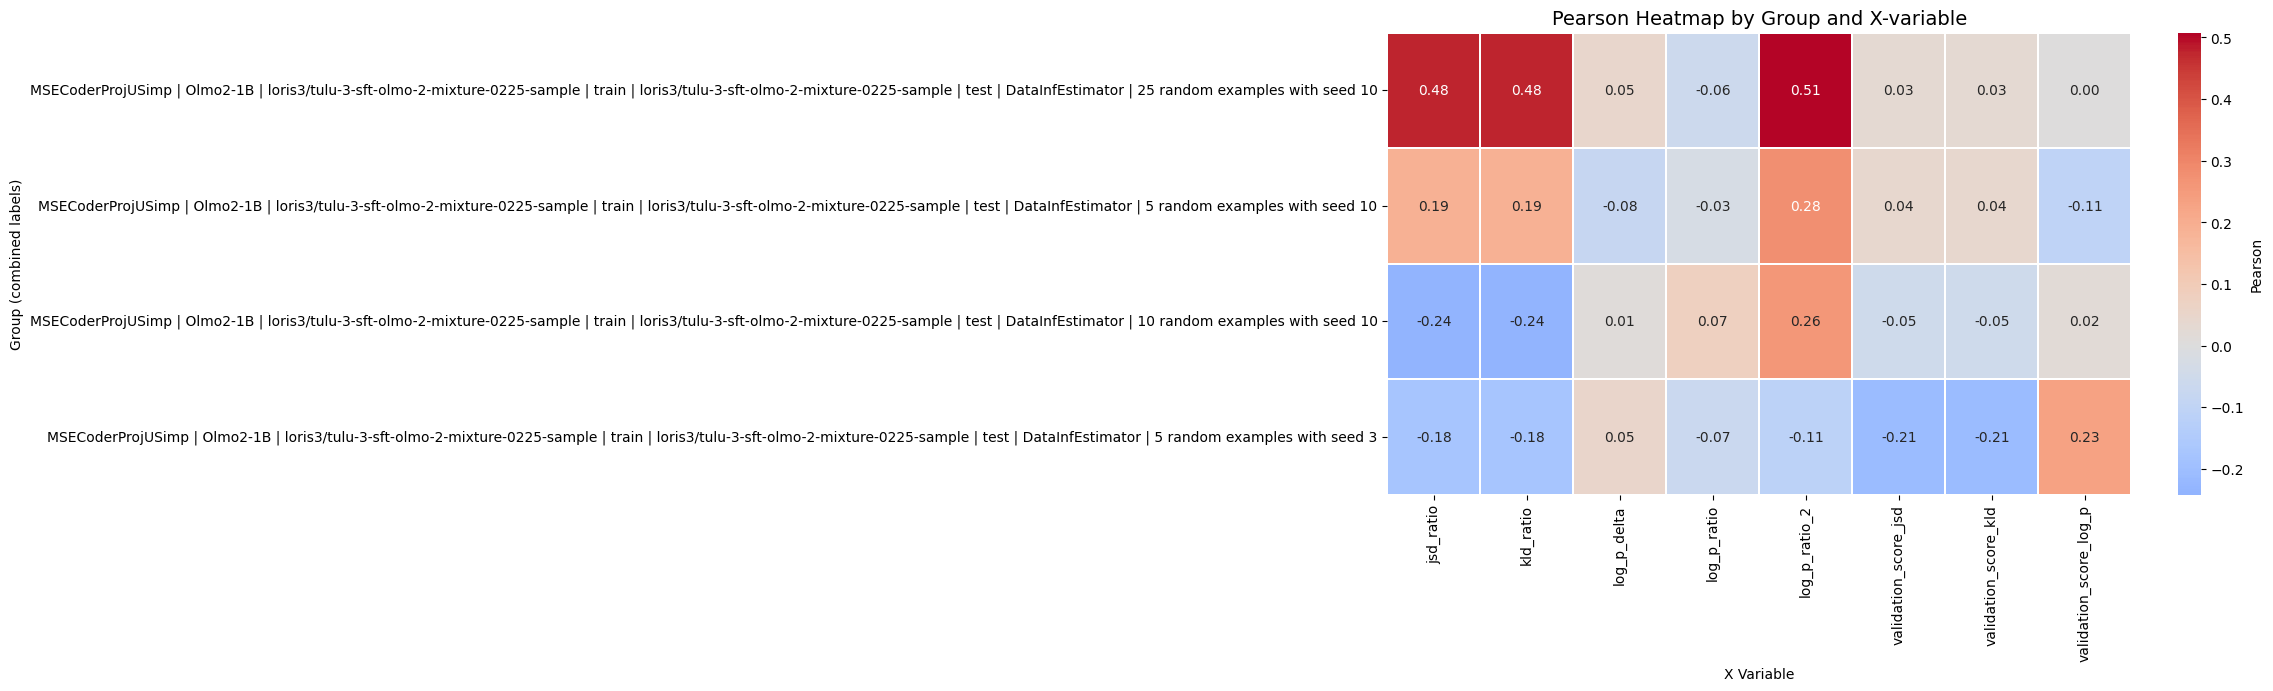

/tmp/ipykernel_3824457/1495757571.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


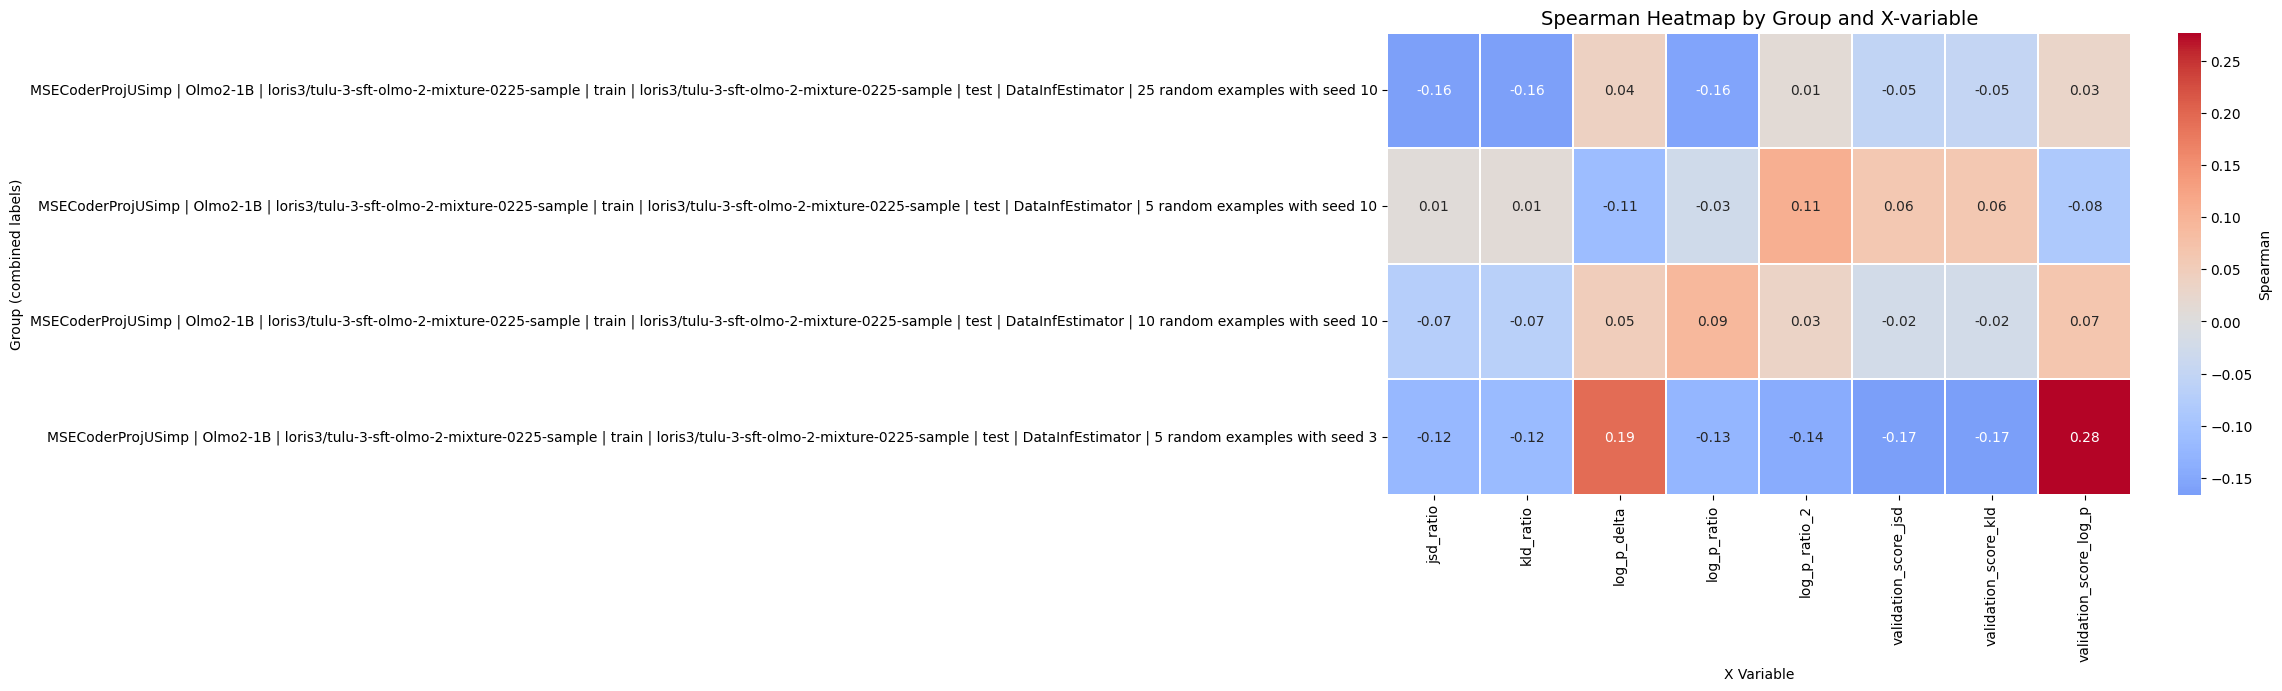

/tmp/ipykernel_3824457/1495757571.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


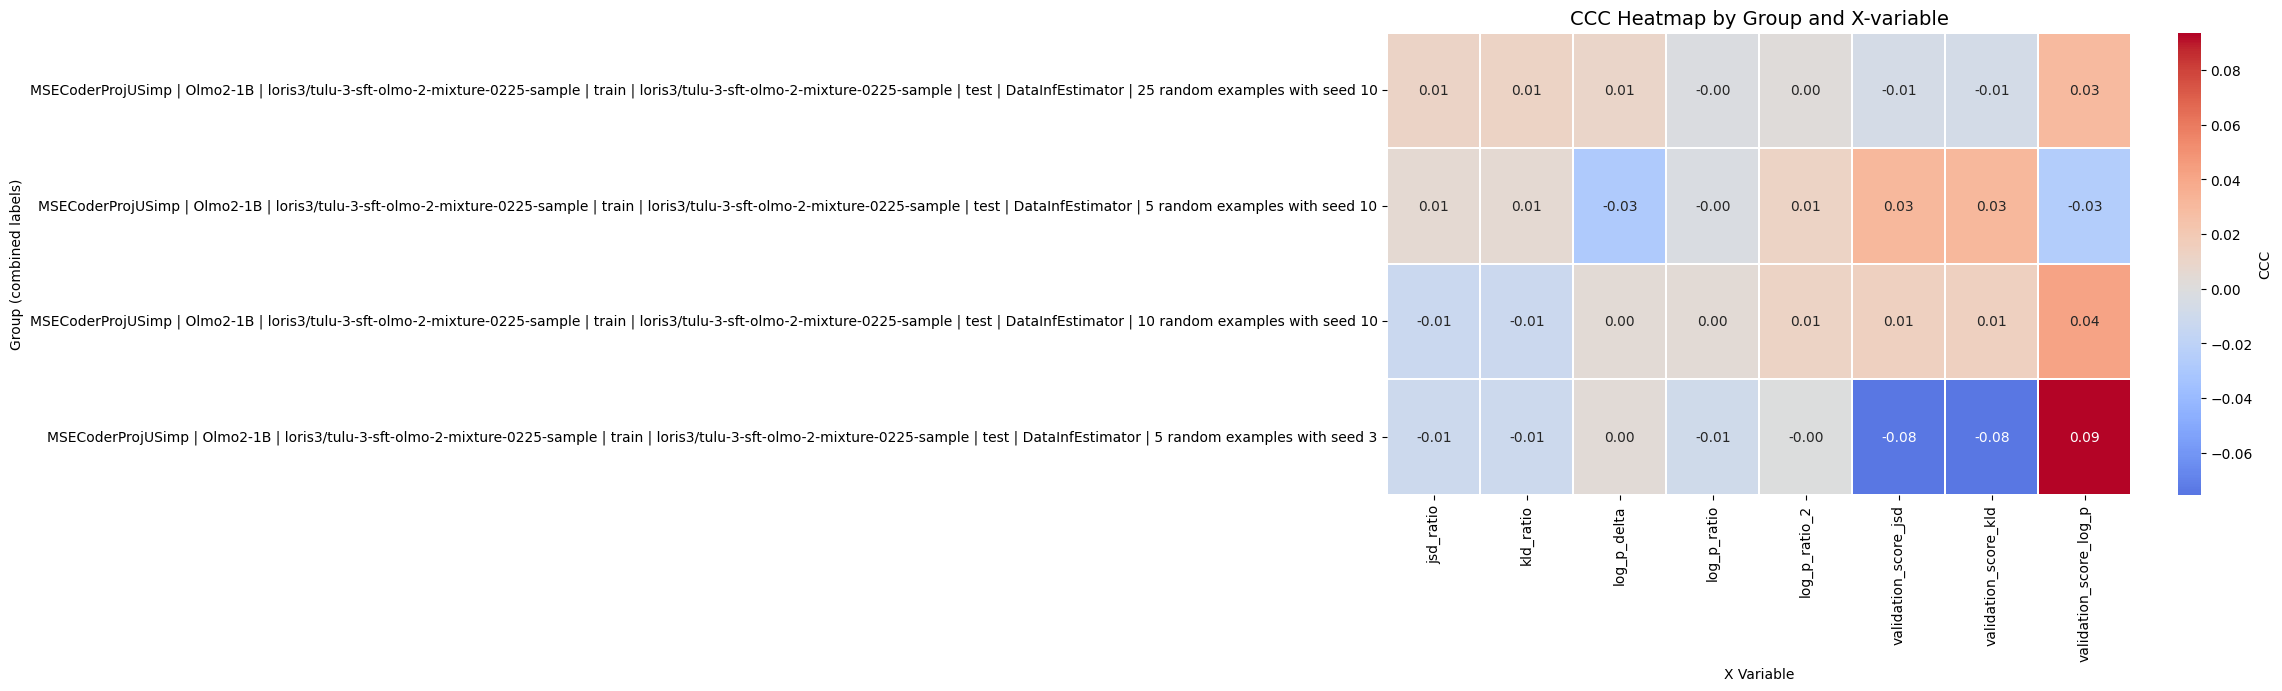

/tmp/ipykernel_3824457/1495757571.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


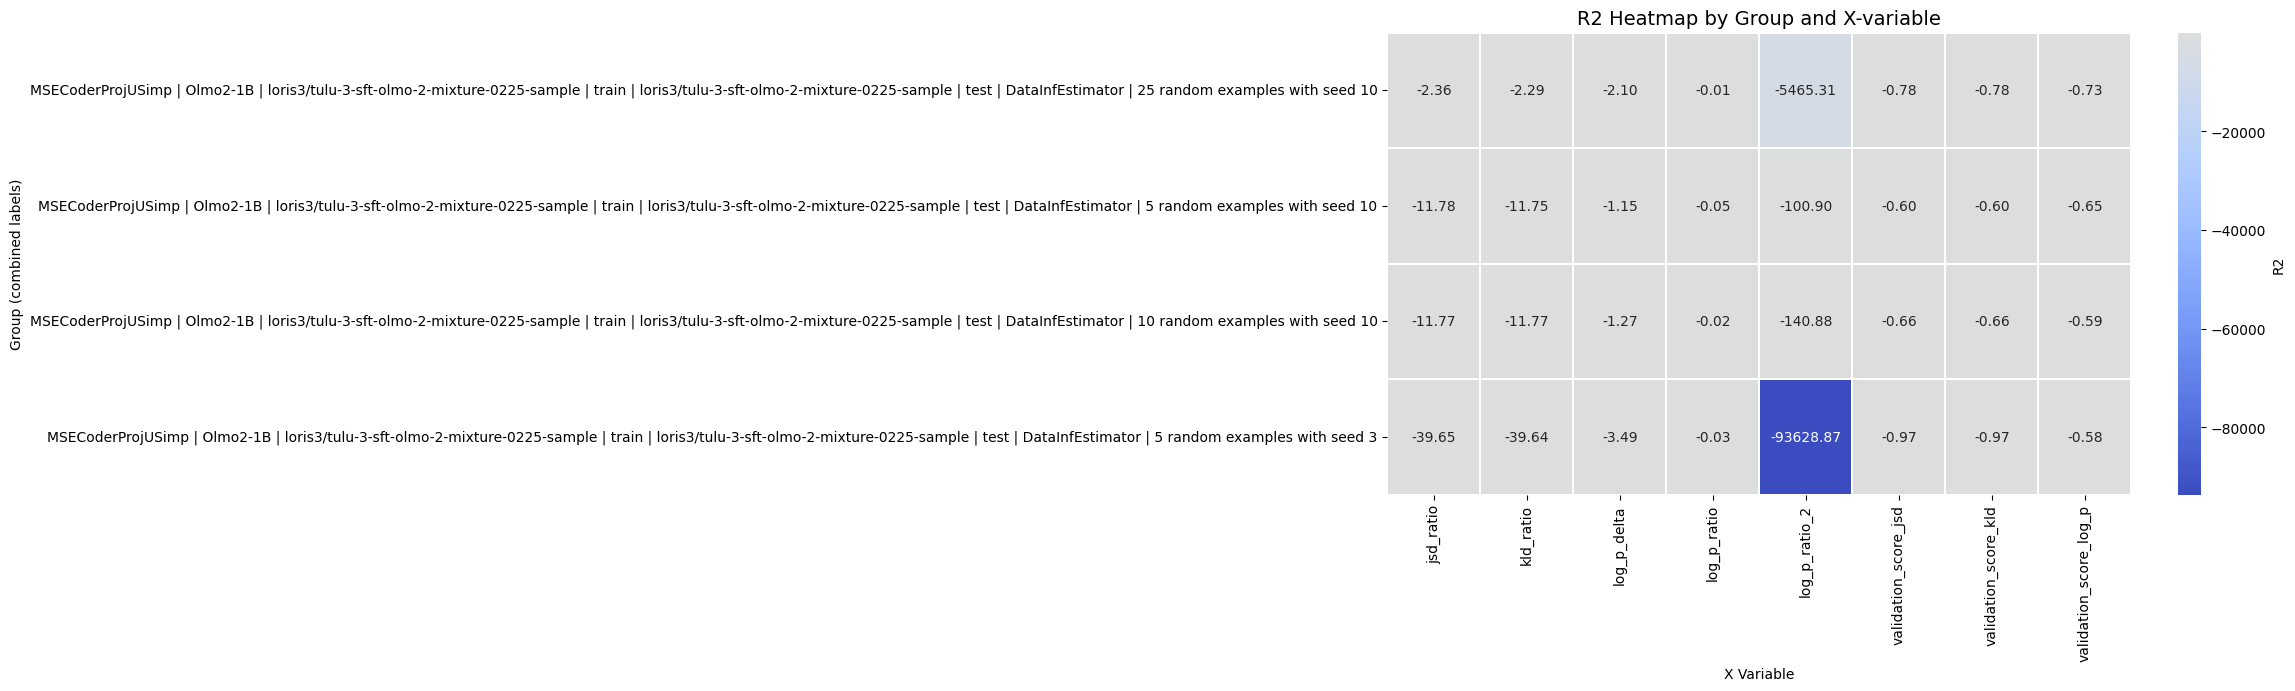

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# -----------------------------
# Combine group columns for labeling
# -----------------------------
report_df["group_label"] = report_df[group_cols].astype(str).agg(" | ".join, axis=1)

# -----------------------------
# Plot heatmaps for each metric
# -----------------------------
metrics = ["Pearson", "Spearman", "CCC", "R2"]


base_metric = "Pearson"
base_pivot = report_df.pivot_table(
    index="group_label",
    columns="X",
    values=base_metric
)
base_order = (
    base_pivot.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

for metric in metrics:
    pivot_df = report_df.pivot_table(
        index="group_label",
        columns="X",
        values=metric
    )
    pivot_df = pivot_df.reindex(base_order)

    # Sort rows by average correlation
    # pivot_df["mean_corr"] = pivot_df.mean(axis=1)
    # pivot_df = pivot_df.sort_values("mean_corr", ascending=False).drop(columns="mean_corr")

    plt.figure(figsize=(12, max(6, 0.4 * len(pivot_df))))
    sns.heatmap(
        pivot_df, annot=True, fmt=".2f",
        cmap="coolwarm", center=0, linewidths=0.3,
        cbar_kws={"label": metric}
    )
    plt.title(f"{metric} Heatmap by Group and X-variable", fontsize=14)
    plt.xlabel("X Variable")
    plt.ylabel("Group (combined labels)")
    plt.tight_layout()
    plt.show()



In [ ]:
 cd5r76t8izohlk

NameError: name 'cd5r76t8izohlk' is not defined

In [ ]:
corr_summary

NameError: name 'corr_summary' is not defined

In [ ]:
rr

In [ ]:
zgfuipdenya,lö

In [ ]:
results_df.groupby(["linear_coder", "explanation_type","model","estimator"]).mean(numeric_only=True)

In [ ]:
from scipy.stats import ttest_rel

results = []

for (k, exp_type,linear_coder), group in results_df.groupby(['k', 'explanation_type', 'linear_coder']):
    # paired test: selection vs random
    t_stat, p_value = ttest_rel(group['validation_score'], group['pred_gain_random'], alternative='greater')
    results.append({'k': k,"linear_coder":linear_coder, 'explanation_type': exp_type, 't_stat': t_stat, 'p_value': p_value})

pd.DataFrame(results)



In [ ]:
from scipy.stats import wilcoxon
w_stat, p_value = wilcoxon(group['validation_score'], group['pred_gain_random'], alternative='greater')
w_stat

In [ ]:
p_value

NameError: name 'p_value' is not defined

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Drop NaNs
df = results_df.dropna(subset=["validation_score", "pred_gain_selection", "pred_gain_random"])

# Mixed-effects model
# 'random_run' is a grouping variable (random intercept)
# You can optionally include 'explanation_type' as another random effect
md = smf.mixedlm(
    "validation_score ~ pred_gain_selection + pred_gain_random",
    df,
    groups=df["random_run"]
)
mdf = md.fit()
print(mdf.summary())


In [ ]:
corr_selection = results_df['validation_score'].corr(results_df['pred_gain_selection'])
corr_random = results_df['validation_score'].corr(results_df['pred_gain_random'])

print(f"Correlation with pred_gain_selection: {corr_selection:.3f}")
print(f"Correlation with pred_gain_random: {corr_random:.3f}")


In [ ]:
import statsmodels.api as sm

# Validation score ~ pred_gain_selection
X1 = sm.add_constant(results_df['pred_gain_selection'])
model1 = sm.OLS(results_df['validation_score'], X1).fit()
print(model1.summary())

# Validation score ~ pred_gain_random
X2 = sm.add_constant(results_df['pred_gain_random'])
model2 = sm.OLS(results_df['validation_score'], X2).fit()
print(model2.summary())


In [ ]:
import statsmodels.api as sm
import pandas as pd

results = []

for keys, group in df.groupby(["explanation_type", "model", "estimator", "linear_coder"]):
    x = -pd.to_numeric(group["mse"], errors="coerce")  # negate MSE so lower is better
    y = pd.to_numeric(group["delta_target_document"], errors="coerce")
    
    mask = ~(x.isna() | y.isna())
    x_clean, y_clean = x[mask], y[mask]
    

    X = sm.add_constant(pd.DataFrame({"neg_mse": x_clean}))
    model = sm.OLS(y_clean, X).fit()
    
    results.append({
        "explanation_type": keys[0],
        "model": keys[1],
        "estimator": keys[2],
        "linear_coder": keys[3],
        "coef": model.params.get("neg_mse", None),       
        "p_value": model.pvalues.get("neg_mse", None),  
        "r_squared": model.rsquared
    })

results_df = pd.DataFrame(results)
results_df


In [ ]:
# import statsmodels.api as sm

# results = []


# for keys, group in df.groupby(["explanation_type", "model", "estimator", "linear_coder"]):
#     x = pd.to_numeric(group["pred_gain"], errors="coerce")
#     y = pd.to_numeric(group["delta_target_document"], errors="coerce")
    
#     mask = ~(x.isna() | y.isna())
#     x_clean, y_clean = x[mask], y[mask]
    

#     X = sm.add_constant(x_clean)
#     model = sm.OLS(y_clean, X).fit()
    
#     results.append({
#         "explanation_type": keys[0],
#         "model": keys[1],
#         "estimator": keys[2],
#         "linear_coder": keys[3],
#         "coef": model.params.get("pred_gain", None),
#         "p_value": model.pvalues.get("pred_gain", None),
#         "r_squared": model.rsquared
#     })


# results_df = pd.DataFrame(results)
# results_df
